In [ ]:
%load_ext autoreload
%autoreload 2
from PyPDF2 import PdfReader
import os
import amrlib
import penman
import torch
from amrlib import load_stog_model
import networkx as nx
import sys, os
from pyvis.network import Network
import matplotlib.pyplot as plt
import amrlib
import spacy
from tools.sentence.sentence import Sentence
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from kg.formatting.formatting_manager import FormattingManager
import sys, importlib,os
sys.modules.pop('PatentTextFormatter', None)
importlib.invalidate_caches()
import numpy as np
from kg.cleaning.normalising.word_normaliser import WordNormaliser
from fastcoref import FCoref
import kg.cleaning.referencing.spacy_pipeline_patent
from tools.sentence.entity import Entity
import torch, os, platform
from kg.generating_kg.generating.NodeGenerator import NodeGenerator
import spacy
from kg.cleaning.referencing.spacy_pipeline_patent import SpacyPipeline

c:\Users\Caleb\Documents\LLM Patent Claim Generator Thesis\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import torch, os, platform

print("torch:", torch.__version__)
print("cuda available:", torch.cuda.is_available())
print("torch.version.cuda:", torch.version.cuda)   # None == CPU-only build
print("gpu count:", torch.cuda.device_count())

if torch.cuda.is_available():
    print("name[0]:", torch.cuda.get_device_name(0))
    print("capability[0]:", torch.cuda.get_device_capability(0))
else:
    print("No CUDA device visible to PyTorch.")

torch: 2.7.1+cu128
cuda available: True
torch.version.cuda: 12.8
gpu count: 1
name[0]: NVIDIA GeForce RTX 5070 Ti
capability[0]: (12, 0)


In [28]:
formatterManager = FormattingManager()
segment_split = formatterManager.split_segments("A computing apparatus configured to dynamically allocate processing resources among a plurality of concurrent machine-learning inference tasks based on predictive workload analysis, wherein said allocation is continuously optimized through feedback derived from real-time performance metrics and latency constraints.")
print("split" + str(segment_split))

11/17/2025 13:44:27 - INFO - 	 Use pytorch device_name: cuda:0
11/17/2025 13:44:27 - INFO - 	 Load pretrained SentenceTransformer: sentence-transformers/all-MiniLM-L6-v2


KeyboardInterrupt: 

In [4]:
nlp = spacy.load("en_core_web_sm")
formatterManager = FormattingManager()
sentence_split = [[]]
for i in range(0,len(segment_split)):
    doc = nlp(segment_split[i])
    sentences = [sent.text.strip() for sent in doc.sents]
    sentence_str = ""
    for c in sentences:
        sentence_split[i].extend(formatterManager.split(c))

print(sentence_split[0])



11/14/2025 19:08:10 - INFO - 	 Use pytorch device_name: cuda:0
11/14/2025 19:08:10 - INFO - 	 Load pretrained SentenceTransformer: sentence-transformers/all-MiniLM-L6-v2


State


11/14/2025 19:08:14 - INFO - 	 HTTP Request: POST https://api.anthropic.com/v1/messages "HTTP/1.1 200 OK"


Raw: ```json
[
  "A computing apparatus is configured to dynamically allocate processing resources among a plurality of concurrent machine-learning inference tasks.",
  "The allocation is based on predictive workload analysis.",
  "Said allocation is continuously optimized through feedback derived from real-time performance metrics and latency constraints."
]
``` State: {'text': 'A computing apparatus is configured to dynamically allocate processing resources among a plurality of concurrent machine-learning inference tasks. Said allocation is continuously optimized through feedback derived from real-time performance metrics and latency constraints.', 'sentences': ['A computing apparatus is configured to dynamically allocate processing resources among a plurality of concurrent machine-learning inference tasks.', 'The allocation is based on predictive workload analysis.', 'Said allocation is continuously optimized through feedback derived from real-time performance metrics and latency co

11/14/2025 19:08:15 - INFO - 	 HTTP Request: POST https://api.anthropic.com/v1/messages "HTTP/1.1 200 OK"


Raw: ```json
[
  "A computing apparatus is configured to dynamically allocate processing resources among a plurality of concurrent machine-learning inference tasks.",
  "Said allocation is continuously optimized through feedback derived from real-time performance metrics and latency constraints."
]
``` State: {'text': 'A computing apparatus is configured to dynamically allocate processing resources among a plurality of concurrent machine-learning inference tasks. Said allocation is continuously optimized through feedback derived from real-time performance metrics and latency constraints.', 'sentences': ['A computing apparatus is configured to dynamically allocate processing resources among a plurality of concurrent machine-learning inference tasks.', 'The allocation is based on predictive workload analysis.', 'Said allocation is continuously optimized through feedback derived from real-time performance metrics and latency constraints.'], 'improvement': None, 'done': True} iteration: 2


In [5]:
rule_based = [[]]
for i, c in enumerate(sentence_split):
    for d in c:
        print("Snip " + d.text)
        rule = formatterManager.rule_standardiser(
            d.text
        )
        rule_based[i].append(rule[i].text)  # replace the old element
print(sentence_split)
print(rule_based[0])


        



Snip A computing apparatus is configured to dynamically allocate processing resources among a plurality of concurrent machine-learning inference tasks.
Run sentence simplifier


11/14/2025 19:08:17 - INFO - 	 HTTP Request: POST https://api.anthropic.com/v1/messages "HTTP/1.1 200 OK"
11/14/2025 19:08:18 - INFO - 	 HTTP Request: POST https://api.anthropic.com/v1/messages "HTTP/1.1 200 OK"
11/14/2025 19:08:20 - INFO - 	 HTTP Request: POST https://api.anthropic.com/v1/messages "HTTP/1.1 200 OK"


Snip The allocation is based on predictive workload analysis.
Run sentence simplifier


11/14/2025 19:08:21 - INFO - 	 HTTP Request: POST https://api.anthropic.com/v1/messages "HTTP/1.1 200 OK"


Snip Said allocation is continuously optimized through feedback derived from real-time performance metrics and latency constraints.
Run sentence simplifier


11/14/2025 19:08:22 - INFO - 	 HTTP Request: POST https://api.anthropic.com/v1/messages "HTTP/1.1 200 OK"
11/14/2025 19:08:23 - INFO - 	 HTTP Request: POST https://api.anthropic.com/v1/messages "HTTP/1.1 200 OK"
11/14/2025 19:08:24 - INFO - 	 HTTP Request: POST https://api.anthropic.com/v1/messages "HTTP/1.1 200 OK"


[[Sentence(text='A computing apparatus is configured to dynamically allocate processing resources among a plurality of concurrent machine-learning inference tasks.', index=0, source='', span=None, id='0f48b2d9-4dae-4421-8ef8-34547a4b3b20', kg_node_id=None, embedding=None, tokens=[], entities={}, tags=[], importance=0.5, info_quality=0.5, novelty=None, lang='en'), Sentence(text='The allocation is based on predictive workload analysis.', index=1, source='', span=None, id='78e7322a-0681-46d4-a475-5fc02d96edd8', kg_node_id=None, embedding=None, tokens=[], entities={}, tags=[], importance=0.5, info_quality=0.5, novelty=None, lang='en'), Sentence(text='Said allocation is continuously optimized through feedback derived from real-time performance metrics and latency constraints.', index=2, source='', span=None, id='f61797e4-06e5-4c4c-a05a-6e34d9410f01', kg_node_id=None, embedding=None, tokens=[], entities={}, tags=[], importance=0.5, info_quality=0.5, novelty=None, lang='en')]]
['A computing a

In [6]:
print(rule_based[0][1])
for c,i in enumerate(rule_based):
    for i in rule_based[c]:
        simplify = formatterManager.simplify(i)
        print(simplify)



[GENERIC] Predictive workload analysis determines the allocation.
['a', 'computing', 'apparatus', 'dynamically', 'allocate', 'processing', 'resource', 'among', 'a', 'plurality', 'of', 'concurrent', 'machine', '-', 'learn', 'inference', 'task', '.']
['[', 'generic', ']', 'predictive', 'workload', 'analysis', 'determine', 'the', 'allocation', '.']
['[', 'assumption', ']', 'the', 'system', 'continuously', 'optimize', 'say', 'allocation', 'through', 'feedback', 'derive', 'from', 'real', '-', 'time', 'performance', 'metric', 'and', 'latency', 'constraint', '.']


In [ ]:
# spacy_pipeline_patent.py (add this at the bottom, optional helper)

pipeline = SpacyPipeline()

sentence1 = Sentence(text="Caleb is soon 22.")
sentence2 = Sentence(text= "Caleb birthday is in half a year.")
sentence3 = Sentence(text="His brother is called Nathan.")
sentence4 = Sentence(text="Nathan is going to be 24 soon.")

sentences = [sentence1, sentence2, sentence3, sentence4]
joined_text = "".join(s.text for s in sentences)
doc = pipeline.nlp(joined_text)
sentence_starts = pipeline.indexes_sentences(sentences)
clusters = pipeline.fill_coref_entities(doc,sentence_starts, sentences)
cluster_spans = pipeline.get_cluster_spans(clusters)
pipeline.add_entities_from_ner(doc,cluster_spans=cluster_spans,sentence_starts=sentence_starts,sentences=sentences)
pipeline.normalise_other_refs_to_first(sentences)
pipeline.generate_normalised_text(sentences)

11/14/2025 19:11:31 - INFO - 	 missing_keys: []
11/14/2025 19:11:31 - INFO - 	 unexpected_keys: []
11/14/2025 19:11:31 - INFO - 	 mismatched_keys: []
11/14/2025 19:11:31 - INFO - 	 error_msgs: []
11/14/2025 19:11:31 - INFO - 	 Model Parameters: 90.5M, Transformer: 82.1M, Coref head: 8.4M
11/14/2025 19:11:31 - INFO - 	 Tokenize 1 inputs...
Map: 100%|██████████| 1/1 [00:00<00:00, 161.31 examples/s]
11/14/2025 19:11:31 - INFO - 	 ***** Running Inference on 1 texts *****
Inference: 100%|██████████| 1/1 [00:00<00:00, 17.98it/s]



Sentence 0: Caleb is soon 22.
  [0:5] Caleb Reference  ref=Caleb
Caleb is soon 22.
  [14:22] 22.Caleb PERSON  ref=22.Caleb
Caleb is soon 22.

Sentence 1: Caleb birthday is in half a year.
  [21:32] half a year DATE  ref=half a year
Caleb birthday is in half a year.

Sentence 2: Caleb brother is called Nathan.
  [0:3] His Reference  ref=Caleb
Caleb brother is called Nathan.
  [22:28] Nathan PERSON  ref=Nathan
Caleb brother is called Nathan.

Sentence 3: Nathan is going to be 24 soon.
  [0:6] Nathan PERSON  ref=Nathan
Nathan is going to be 24 soon.
  [22:24] 24 DATE  ref=24
Nathan is going to be 24 soon.


In [11]:

from sentence_transformers import SentenceTransformer
model = SentenceTransformer("all-MiniLM-L6-v2")
DIM = model.get_sentence_embedding_dimension()

def embed_word(w: str) -> np.ndarray:
    v = model.encode(w, normalize_embeddings=True)
    return np.asarray(v, dtype="float32")

norm = WordNormaliser(embed_fn=embed_word, dim=DIM, threshold=0.72)


11/14/2025 19:12:10 - INFO - 	 Use pytorch device_name: cuda:0
11/14/2025 19:12:10 - INFO - 	 Load pretrained SentenceTransformer: all-MiniLM-L6-v2


In [12]:
amrlib.__file__
stog = amrlib.load_stog_model()


In [25]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Load the AMR model and move to GPU
stog = amrlib.load_stog_model()
if torch.cuda.is_available():
    stog.model.to('cuda')
    stog.device = torch.device('cuda')
else:
    stog.device = torch.device('cpu')

sentences = [
    'Caleb is 21',
    'Caleb lives in Munich',
    'Caleb was born in Berlin',
    'Nathan lives in Marburg',
    'Nathan and Caleb are brothers',
    'Emma is 19',
    'Emma studies biology',
    'Emma lives in Berlin',
    'Caleb and Emma are friends',
    'Nathan studies engineering',
    'Caleb works at a bookstore',
    'Emma likes music',
    'Nathan likes football',
    'Caleb and Nathan play football together',
    'Emma has a cat',
    'Caleb likes Emma’s cat',
    'Nathan has a dog',
    'Caleb and Nathan walk the dog on weekends',
    'Emma and Caleb go to concerts',
    'Caleb’s favorite band is Coldplay',
    'Emma studies at Humboldt University',
    'Nathan studies at Marburg University',
    'Caleb visits Nathan in Marburg',
    'Emma and Nathan met last summer',
    'Emma and Caleb met at school',
    'Caleb’s mother is a teacher',
    'Nathan’s father is a doctor',
    'Emma’s brother is 15',
    'Caleb and Nathan grew up in Berlin',
    'Caleb moved to Munich last year',
    'Nathan stayed in Marburg for his studies',
    'Emma and Nathan text often',
    'Caleb calls Emma on weekends',
    'Nathan and Caleb visit their parents in Berlin',
    'Emma likes to travel',
    'Caleb wants to visit Paris',
    'Nathan visited Paris last year',
    'Emma and Caleb plan to visit Paris together',
    'Caleb likes coffee',
    'Emma prefers tea',
    'Nathan drinks tea in the morning',
    'Caleb and Nathan share an apartment in summer',
    'Emma comes over for dinner sometimes',
    'Caleb cooks pasta often',
    'Nathan helps with dishes',
    'Emma brings dessert',
    'Caleb and Emma take photos together',
    'Nathan posts photos on social media',
    'Emma studies every morning',
    'Caleb goes jogging in the park',
    'Nathan rides his bike to university'
]
#sentences = [sentence1, sentence2,sentence3,sentence4]
#sent_texts = [s.text for s in sentences]
#amr_strings = stog.parse_sents(sent_texts)        # list of AMR strings
#amr_graphs = [penman.decode(s) for s in amr_strings]
#sentences_g = list()

generator_run = NodeGenerator().run("[_caleb123_person] is going to [school123_building]")
print(generator_run)




#for i, s in enumerate(amr_strings):
 #   print(f"\nAMR {i}:")
  #  print(s)





KeyboardInterrupt: 

In [ ]:
import re
import networkx as nx
from uuid import uuid4
nx_graph = nx.MultiDiGraph()

for g in amr_graphs:
    for src, role, tgt in g.triples:
        if role == 'instance':
            continue       # skip concept declarations
        nx_graph.add_node(src,concept=)
        nx_graph.add_node(tgt)

    # Add edges for triples
    for src, role, tgt in g.triples:
        nx_graph.add_edge(src, tgt, role=role)




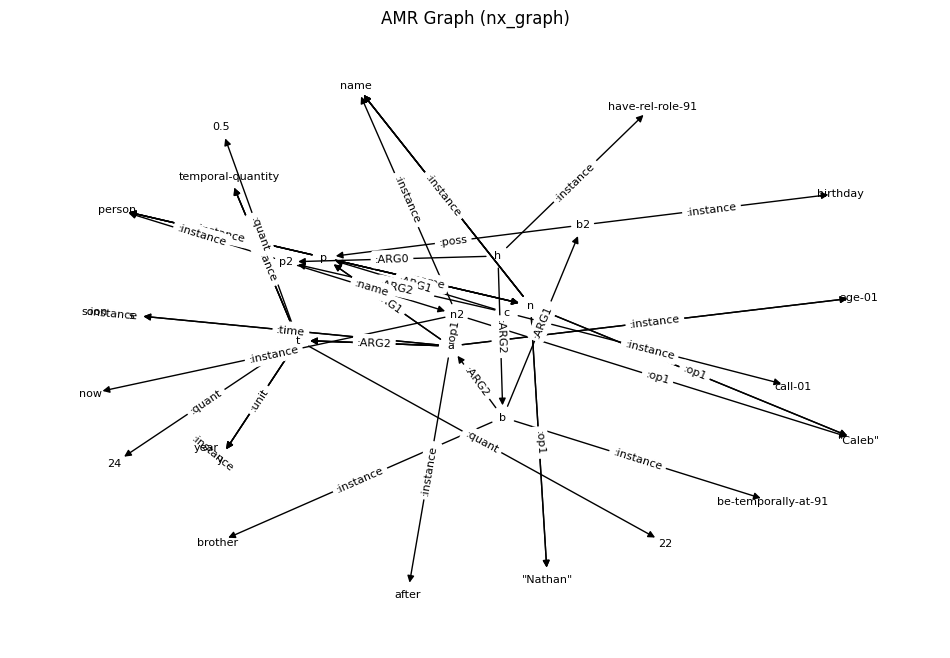

amr_graph.html
✅ Interactive graph written to amr_graph.html — open it in your browser.


In [20]:
# --- visualize nx_graph ---
import matplotlib.pyplot as plt
from pyvis.network import Network
import networkx as nx

# Assign shapes and colors based on node type
for n, d in nx_graph.nodes(data=True):
    if d.get("kind") == "concept":
        d["shape"] = "square"
        d["color"] = "#9ddaff"
    elif d.get("kind") == "literal":
        d["shape"] = "hexagon"
        d["color"] = "#fbe29c"
    else:
        d["shape"] = "circle"
        d["color"] = "#cbe5b6"

# ---- Matplotlib static visualization ----
pos = nx.spring_layout(nx_graph, seed=42)
plt.figure(figsize=(12, 8))

kind_to_shape = {"concept": "s", "literal": "h", "other": "o"}

for kind, shape in kind_to_shape.items():
    nodes = [n for n, d in nx_graph.nodes(data=True) if d.get("kind") == kind]
    if nodes:
        nx.draw_networkx_nodes(
            nx_graph, pos, nodelist=nodes,
            node_shape=shape,
            node_color=[nx_graph.nodes[n]["color"] for n in nodes],
            node_size=1200, edgecolors="black"
        )

# Use .get("label") first, then fall back to concept or id
node_labels = {
    n: (d.get("label") or d.get("concept") or n)
    for n, d in nx_graph.nodes(data=True)
}
nx.draw_networkx_labels(nx_graph, pos, labels=node_labels, font_size=8)

nx.draw_networkx_edges(nx_graph, pos, arrows=True, arrowstyle="-|>")

edge_labels = {(u, v): d.get("role", "") for u, v, d in nx_graph.edges(data=True)}
nx.draw_networkx_edge_labels(nx_graph, pos, edge_labels=edge_labels, font_size=8)

plt.title("AMR Graph (nx_graph)")
plt.axis("off")
plt.show()

# ---- PyVis interactive visualization ----
net = Network(height="700px", width="100%", directed=True, notebook=True)
net.barnes_hut()

for n, d in nx_graph.nodes(data=True):
    net.add_node(
        n,
        label=d.get("label") or d.get("concept") or n,
        color=d.get("color", "#cbe5b6"),
        shape="box" if d.get("shape") == "square" else "ellipse",
        title=f"id: {n}<br>kind: {d.get('kind', '')}"
)


for u, v, d in nx_graph.edges(data=True):
    net.add_edge(u, v, label=d.get("role", ""), arrows="to")

net.show("amr_graph.html")
print("✅ Interactive graph written to amr_graph.html — open it in your browser.")


In [21]:
# ---- PyVis interactive visualization ----
net = Network(height="700px", width="100%", directed=True, notebook=True)
net.barnes_hut()

for n, d in nx_graph.nodes(data=True):
    net.add_node(
    n,
    label=d.get("label") or d.get("concept") or n,
    color=d.get("color", "#cbe5b6"),
    shape="box" if d.get("shape") == "square" else "ellipse",
    title=f"id: {n}<br>kind: {d.get('kind', '')}"
)


for u, v, d in nx_graph.edges(data=True):
    net.add_edge(u, v, label=d.get("role", ""), arrows="to")

net.show("amr_graph.html", notebook=None)
print("✅ Interactive graph written to amr_graph.html — open it in your browser.")


amr_graph.html
✅ Interactive graph written to amr_graph.html — open it in your browser.


Each sentence converted to Sentence.py with all tokens in and tags like [Boilerplate] [Ambigous] or references like [1j123jS] = Main Device

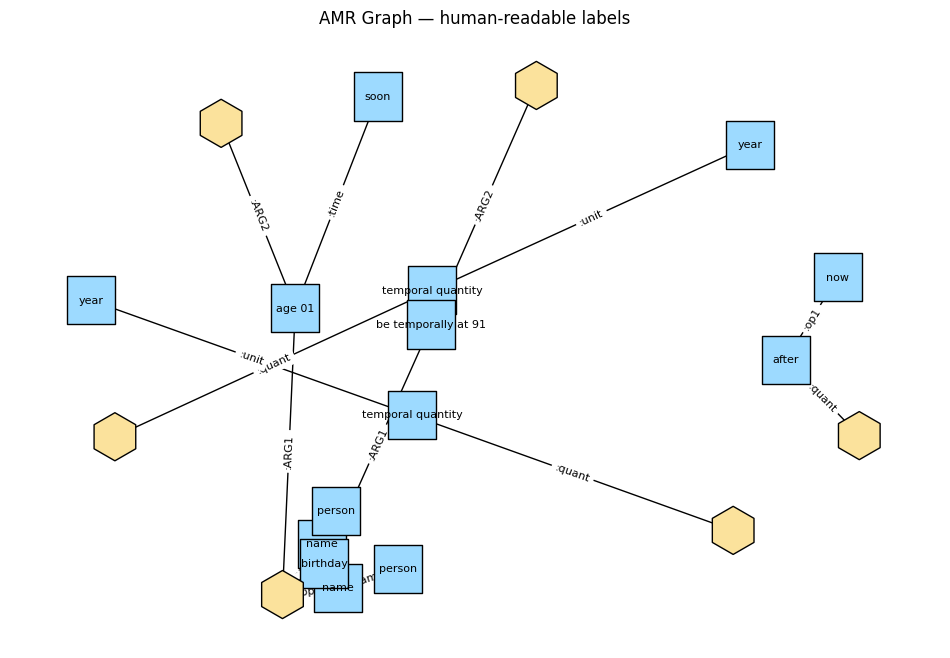

amr_graph.html
✅ Updated labels. Open amr_graph.html to explore interactively.


In [54]:
# --- Make node labels human-readable (use :name, :instance, :wiki) and re-render ---
from pyvis.network import Network
import re

# 1) Build helper maps from the PENMAN graph
inst = {s: t for s, r, t in g.triples if r == ":instance"}  # var -> concept

# Gather :name ops (op1/op2/...) and :wiki
name_parts = {}  # var -> [op1, op2, ...]
wiki = {}        # var -> "Qxxxx" or page

for s, r, t in g.triples:
    if r == ":wiki":
        wiki[s] = str(t).strip('"')
    elif r.startswith(":op"):
        # Only consider ops for nodes that have a :name relation
        # AMR often encodes names as: (x / person :name (n / name :op1 "John" :op2 "Doe"))
        # But in triple form, ops still reference the same source var as :name subtree var.
        name_parts.setdefault(s, []).append(str(t).strip('"'))
    elif r == ":name":
        # mark this var as having a name container; ops will attach to this var
        name_parts.setdefault(s, [])

# Also handle cases where name container is a separate var:
# If there are triples like (x :name n) and (n :op1 "Foo"), re-map ops from 'n' to 'x'.
name_container_edges = [(s, t) for s, r, t in g.triples if r == ":name"]
container_to_host = {container: host for host, container in name_container_edges}
if container_to_host:
    remap = {}
    for var, parts in list(name_parts.items()):
        if var in container_to_host:
            host = container_to_host[var]
            remap.setdefault(host, [])
            remap[host].extend(parts)
            del name_parts[var]
    for host, parts in remap.items():
        name_parts.setdefault(host, []).extend(parts)

# 2) Compute a pretty label for each node
def pretty_label(var_id, data):
    kind = data.get("kind")
    concept = data.get("concept", "")
    parts = name_parts.get(var_id, [])
    name_str = " ".join(parts).strip()
    if kind == "literal":
        return concept  # literal node already stores the text as 'concept'
    # Prefer explicit name if present
    if name_str:
        return name_str
    # Fall back to concept, title-case for readability (avoid overdoing for acronyms)
    if concept:
        # keep hyphens/underscores readable
        return re.sub(r"[_-]+", " ", str(concept)).strip()
    # Final fallback: the variable ID itself
    return str(var_id)

# 3) Attach labels, wiki, and root flag to nodes
root_var = getattr(g, "top", None)
for n, d in nx_graph.nodes(data=True):
    d["label"] = pretty_label(n, d)
    if n in wiki:
        d["wiki"] = wiki[n]
    if root_var is not None and n == root_var:
        d["root"] = True

# 4) Quick static check with matplotlib labels = node['label']
pos = nx.spring_layout(nx_graph, seed=7)
plt.figure(figsize=(12, 8))
for kind, shape in {"concept": "s", "literal": "h", "other": "o"}.items():
    nodes = [n for n, d in nx_graph.nodes(data=True) if d.get("kind") == kind]
    if nodes:
        nx.draw_networkx_nodes(
            nx_graph, pos, nodelist=nodes,
            node_shape=shape,
            node_color=[nx_graph.nodes[n].get("color", "#cbe5b6") for n in nodes],
            node_size=1200, edgecolors="black",
        )

nx.draw_networkx_edges(nx_graph, pos, arrows=True, arrowstyle="-|>")
nx.draw_networkx_labels(nx_graph, pos,
                        labels={n: d.get("label", n) for n, d in nx_graph.nodes(data=True)},
                        font_size=8)
nx.draw_networkx_edge_labels(nx_graph, pos,
                             edge_labels={(u, v): d.get("role", "") for u, v, d in nx_graph.edges(data=True)},
                             font_size=8)
plt.title("AMR Graph — human-readable labels")
plt.axis("off")
plt.show()

# 5) PyVis interactive with nice tooltips
net = Network(height="700px", width="100%", directed=True, notebook=True)
net.barnes_hut()

for n, d in nx_graph.nodes(data=True):
    hover = (
        f"<b>id</b>: {n}"
        f"<br><b>concept</b>: {d.get('concept','')}"
        f"<br><b>label</b>: {d.get('label','')}"
        + (f"<br><b>wiki</b>: {d.get('wiki')}" if d.get("wiki") else "")
        + (f"<br><b>root</b>: {d.get('root')}" if d.get("root") else "")
    )
    net.add_node(
        n,
        label=d.get("label", str(n)),
        title=hover,
        color=d.get("color", "#cbe5b6"),
        shape="box" if d.get("shape") == "square" else ("hexagon" if d.get("shape") == "hexagon" else "ellipse"),
    )

for u, v, d in nx_graph.edges(data=True):
    net.add_edge(u, v, label=d.get("role", ""), arrows="to")

net.show("amr_graph.html" , notebook=None)
print("✅ Updated labels. Open amr_graph.html to explore interactively.")


In [14]:
import os, pyvis, jinja2, sys
print("pyvis:", pyvis.__version__, "->", pyvis.__file__)
print("jinja2:", jinja2.__version__)
# Check if the template exists on disk:
tmpl_dir = os.path.join(os.path.dirname(pyvis.__file__), "templates")
print("template dir exists:", os.path.isdir(tmpl_dir))
if os.path.isdir(tmpl_dir):
    print("has template.html:", os.path.isfile(os.path.join(tmpl_dir, "template.html")))


pyvis: 0.3.2 -> c:\Users\Caleb\Documents\LLM Patent Claim Generator Thesis\.venv\Lib\site-packages\pyvis\__init__.py
jinja2: 3.1.6
template dir exists: True
has template.html: True


In [ ]:
##traversing

